# Relatório Técnico — Tech Challenge Fase 1
## Diagnóstico de Síndrome dos Ovários Policísticos (PCOS) via Machine Learning

**Grupo 62**

| Aluno |
| --- |
| Gabriel Pontin Buranello |
| Jeferson Verdan Oliveira |
| Josue Monteiro de Oliveira |
| Larissa Nunes da Silva |
| Oryange Dafny Strifezze |

**Pós-graduação em Inteligência Artificial para Devs — FIAP**  
**Fase 1 — 2026**

---

**Links do projeto:**

- **Repositório GitHub:** <https://github.com/oryange/tech-challenge-group-62>
- **Vídeo de apresentação (YouTube):** <https://youtu.be/hvWllv-rNHU>

---
## 1. Contextualização do Problema

A Síndrome dos Ovários Policísticos (PCOS, do inglês *Polycystic Ovary Syndrome*) é um distúrbio endócrino-metabólico que afeta entre 6% e 12% das mulheres em idade reprodutiva. É a principal causa de infertilidade por ausência de ovulação no mundo: o desequilíbrio hormonal característico da síndrome impede o desenvolvimento completo dos folículos ovarianos, fazendo com que a mulher não libere óvulos regularmente — condição chamada de anovulação. Seu diagnóstico é baseado no Consenso de Rotterdam (2003), que exige a presença de pelo menos dois dos três critérios: irregularidade ou ausência de ovulação, excesso de andrógenos (hormônios masculinos) e ovários policísticos identificados por ultrassonografia.

O diagnóstico precoce é clinicamente relevante pois a PCOS está associada a comorbidades de longo prazo como resistência à insulina, diabetes tipo 2, hipertensão, dislipidemia e maior risco cardiovascular. Apesar disso, o diagnóstico é frequentemente tardio ou incorreto devido à heterogeneidade de apresentações clínicas.

Neste contexto, o objetivo do projeto é construir modelos preditivos baseados em Machine Learning capazes de auxiliar equipes clínicas na identificação de pacientes com PCOS a partir de dados laboratoriais, hormonais e clínicos, funcionando como ferramenta de suporte à decisão médica — e nunca como substituto ao julgamento do profissional de saúde.

---
## 2. Dataset

**Fonte:** Kaggle — [Polycystic Ovary Syndrome (PCOS) Dataset](https://www.kaggle.com/datasets/prasoonkottarathil/polycystic-ovary-syndrome-pcos)

O projeto utilizou dois arquivos complementares, ambos explorados individualmente na fase de EDA (notebooks `01_eda_infertility.ipynb` e `01_eda_without_infertility.ipynb`):

| Arquivo | Dimensões | Descrição |
| --- | --- | --- |
| `PCOS_data_without_infertility.xlsx` | 541 × 45 | Dataset principal com dados clínicos, hormonais, metabólicos e de ultrassom |
| `PCOS_infertility.csv` | 541 × 6 | Subconjunto hormonal com `I beta-HCG`, `II beta-HCG` e `AMH` das mesmas 541 pacientes |

As duas fontes compartilham as mesmas 541 pacientes e as três colunas do CSV (`I beta-HCG`, `II beta-HCG`, `AMH`) já estão incorporadas no Excel. O CSV foi explorado separadamente para isolar e entender o comportamento desses marcadores hormonais por classe antes da análise conjunta. A modelagem utilizou o dataset unificado do Excel, que contém todas as features — incluindo os marcadores hormonais provenientes do CSV.

**Variável alvo:** `PCOS (Y/N)` — classificação binária (0 = sem PCOS, 1 = com PCOS)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)
import shap

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Carregamento
df = pd.read_excel('../data/PCOS_data_without_infertility.xlsx', sheet_name='Full_new')

print(f'Dimensões: {df.shape}')
df.head(3)

Dimensões: (541, 45)


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN


---
## 3. Exploração de Dados

A análise exploratória abrangeu inspeção de dimensões e tipos, estatísticas descritivas, distribuição da variável alvo e análise de cada feature segmentada por classe.

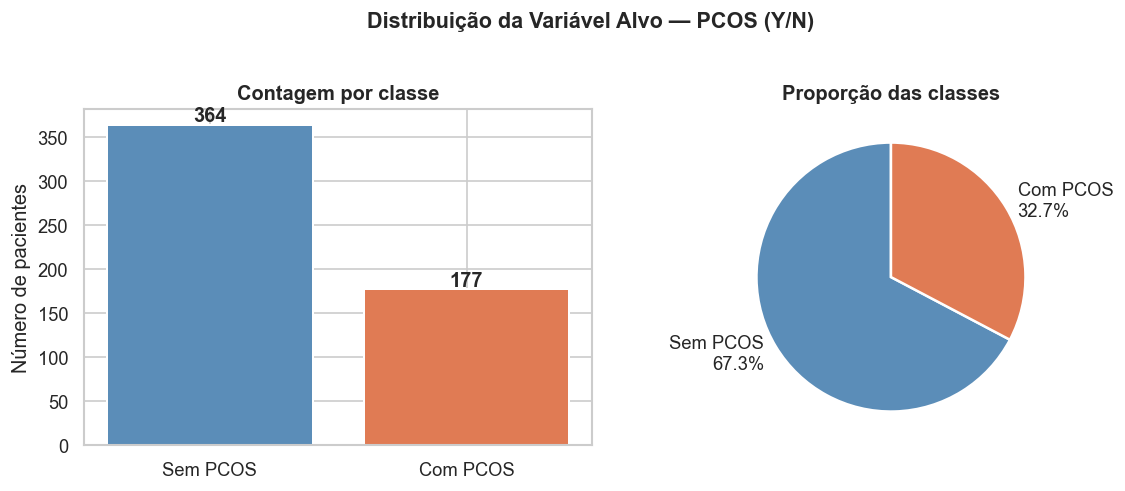

In [2]:
# Distribuição da variável alvo
target_counts = df['PCOS (Y/N)'].value_counts()
labels = ['Sem PCOS', 'Com PCOS']
colors = ['#5B8DB8', '#E07B54']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(labels, target_counts.values, color=colors, edgecolor='white', linewidth=1.2)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 4, str(v), ha='center', fontweight='bold')
axes[0].set_title('Contagem por classe', fontweight='bold')
axes[0].set_ylabel('Número de pacientes')

axes[1].pie(
    target_counts.values,
    labels=[f'{l}\n{v/sum(target_counts.values)*100:.1f}%' for l, v in zip(labels, target_counts.values)],
    colors=colors, startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[1].set_title('Proporção das classes', fontweight='bold')

plt.suptitle('Distribuição da Variável Alvo — PCOS (Y/N)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Há um desequilíbrio moderado de aproximadamente 2:1 (67,3% sem PCOS / 32,7% com PCOS), considerado nas decisões de modelagem e avaliação.

**Principais achados da exploração — features com maior diferença entre classes:**

| Feature | Média sem PCOS | Média com PCOS | Variação | Interpretação clínica |
| --- | --- | --- | --- | --- |
| LH (mIU/mL) | 2,61 | 14,40 | +451% | Elevação do LH é critério diagnóstico |
| FSH (mIU/mL) | 19,19 | 5,17 | −73% | Inversão da razão FSH/LH caracteriza PCOS |
| Crescimento de pelos | — | — | +342% | Marcador de hiperandrogenismo |
| Escurecimento da pele | — | — | +304% | Acanthosis nigricans — resistência insulínica |
| Ganho de peso | — | — | +200% | Associado à resistência insulínica |
| Contagem de folículos (E/D) | — | — | ~+125% | Critério de Rotterdam por ultrassom |
| AMH (ng/mL) | 4,54 | 7,84 | +73% | Marcador de reserva ovariana |

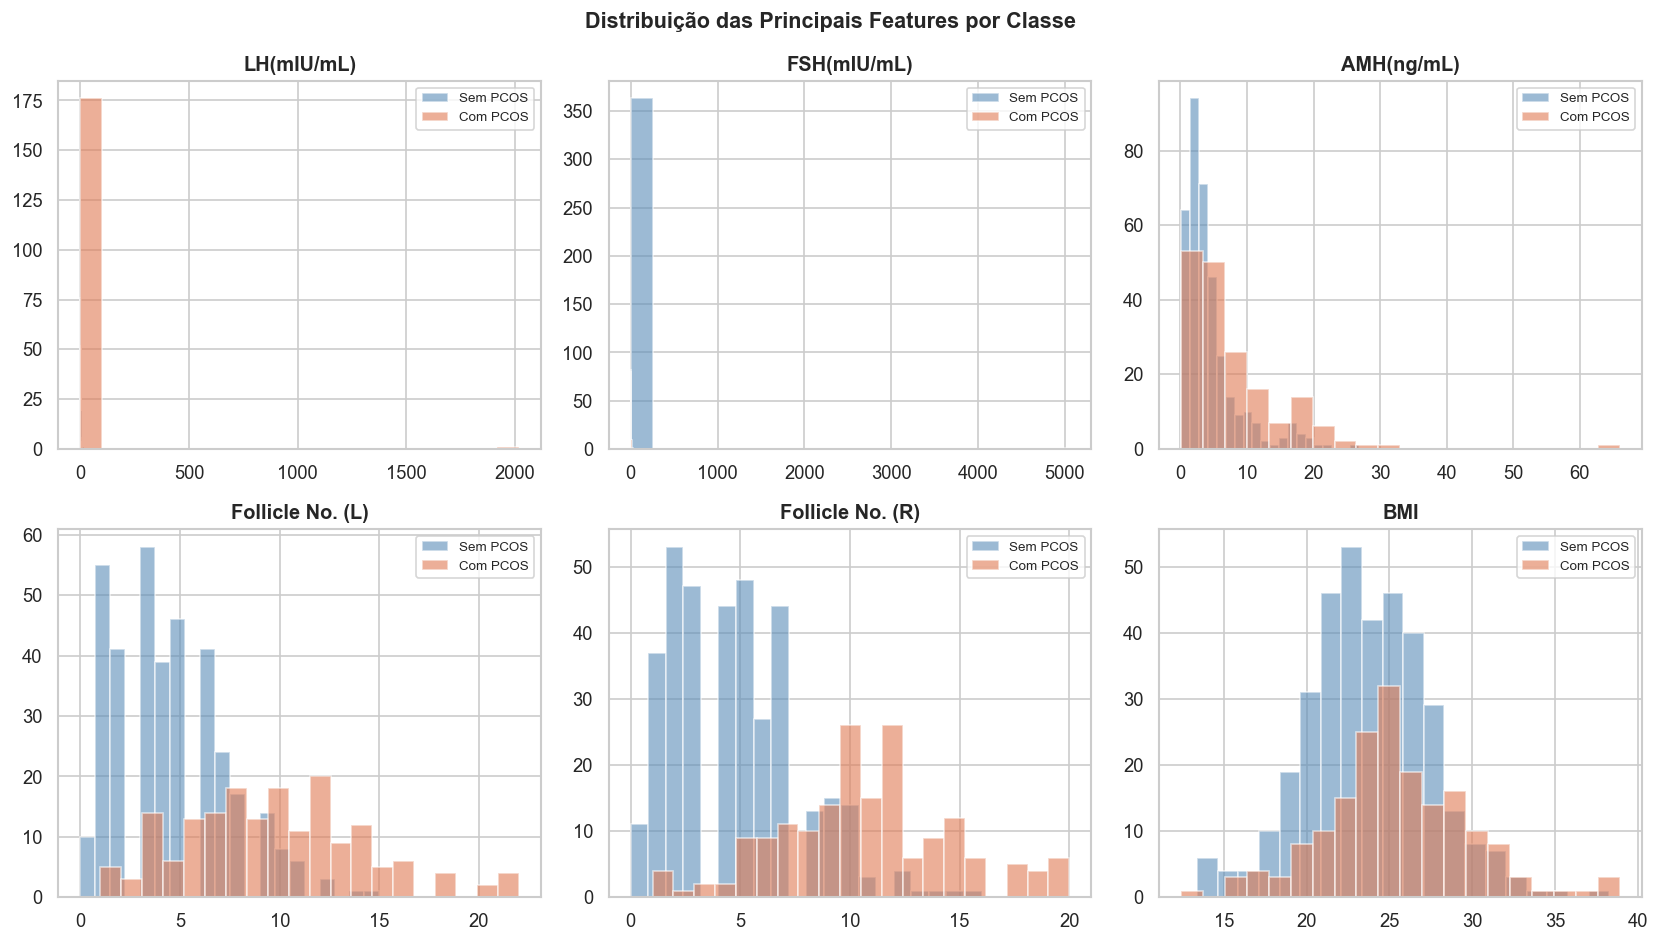

In [3]:
# Estatísticas descritivas por classe
key_features = ['LH(mIU/mL)', 'FSH(mIU/mL)', 'AMH(ng/mL)', 'Follicle No. (L)', 'Follicle No. (R)', 'BMI']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    if feat in df.columns:
        col = pd.to_numeric(df[feat], errors='coerce')
        for label, color in zip([0, 1], colors):
            subset = col[df['PCOS (Y/N)'] == label].dropna()
            axes[i].hist(subset, bins=20, alpha=0.6, color=color,
                         label='Sem PCOS' if label == 0 else 'Com PCOS', edgecolor='white')
        axes[i].set_title(feat, fontweight='bold')
        axes[i].legend(fontsize=8)

plt.suptitle('Distribuição das Principais Features por Classe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Pré-processamento de Dados

### 4.1 Limpeza

Colunas removidas por não contribuírem para a modelagem:
- `Sl. No` e `Patient File No.` — identificadores sem valor preditivo
- `Unnamed: 44` — artefato do Excel com 539 de 541 valores nulos (>99%)

### 4.2 Conversão de variáveis
As colunas `II beta-HCG (mIU/mL)` e `AMH (ng/mL)` estão presentes no arquivo Excel com dtype `object` devido a entradas não numéricas inseridas na origem do dataset Kaggle (as mesmas entradas também aparecem no `PCOS_infertility.csv`, explorado separadamente no EDA). A conversão com `pd.to_numeric(errors='coerce')` transforma esses valores em `NaN`, que são tratados na etapa de imputação seguinte.

### 4.3 Tratamento de valores ausentes
Imputação pela mediana (`SimpleImputer(strategy='median')`), robusta a outliers e adequada para distribuições assimétricas como as do dataset.

### 4.4 Normalização
`StandardScaler` ajustado exclusivamente no conjunto de treino e aplicado nos demais, evitando *data leakage*. Obrigatório para KNN (distâncias euclidianas) e Regressão Logística.

### 4.5 Divisão treino/validação/teste
Split estratificado para preservar a proporção de classes (67%/33%) em todos os subconjuntos:
- **Treino (60%, ~324 amostras):** ajuste dos modelos
- **Validação (20%, ~108 amostras):** seleção de hiperparâmetros — usada para escolher `max_depth` da Árvore de Decisão
- **Teste (20%, ~109 amostras):** avaliação final, mantido completamente isolado até a etapa de resultados

O KNN utilizou validação cruzada de 5 folds no conjunto de treino para selecionar K, o que é mais robusto que uma única divisão treino/validação quando o dataset é pequeno.

### 4.6 Estratégia para desequilíbrio de classes

O dataset apresenta desequilíbrio moderado de 2:1 (67,3% sem PCOS / 32,7% com PCOS). Esse nível é considerado **suave** na literatura — desequilíbrios relevantes geralmente excedem 10:1. Por isso, optou-se por não aplicar técnicas de balanceamento (SMOTE, oversampling ou `class_weight='balanced'`) pelos seguintes motivos:

- O **F1-Score** foi adotado como métrica principal de seleção, sendo intrinsecamente mais sensível ao desempenho na classe minoritária do que a acurácia
- Geração de amostras sintéticas (SMOTE) com apenas 541 pacientes reais poderia introduzir ruído e não refletir apresentações clínicas reais
- Os resultados obtidos no conjunto de teste confirmam que os modelos conseguem identificar a classe positiva mesmo sem balanceamento explícito

In [4]:
# Pipeline de pré-processamento
cols_to_drop = ['Sl. No', 'Patient File No.', 'Unnamed: 44']
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

for col in ['II    beta-HCG(mIU/mL)', 'AMH(ng/mL)']:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

X = df_clean.drop(columns=['PCOS (Y/N)'])
y = df_clean['PCOS (Y/N)']

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

X_temp, X_test, y_temp, y_test = train_test_split(X_imputed, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f'Treino:    {X_train.shape[0]} amostras')
print(f'Validação: {X_val.shape[0]} amostras')
print(f'Teste:     {X_test.shape[0]} amostras')

Treino:    324 amostras
Validação: 108 amostras
Teste:     109 amostras


### 4.7 Análise de Correlação

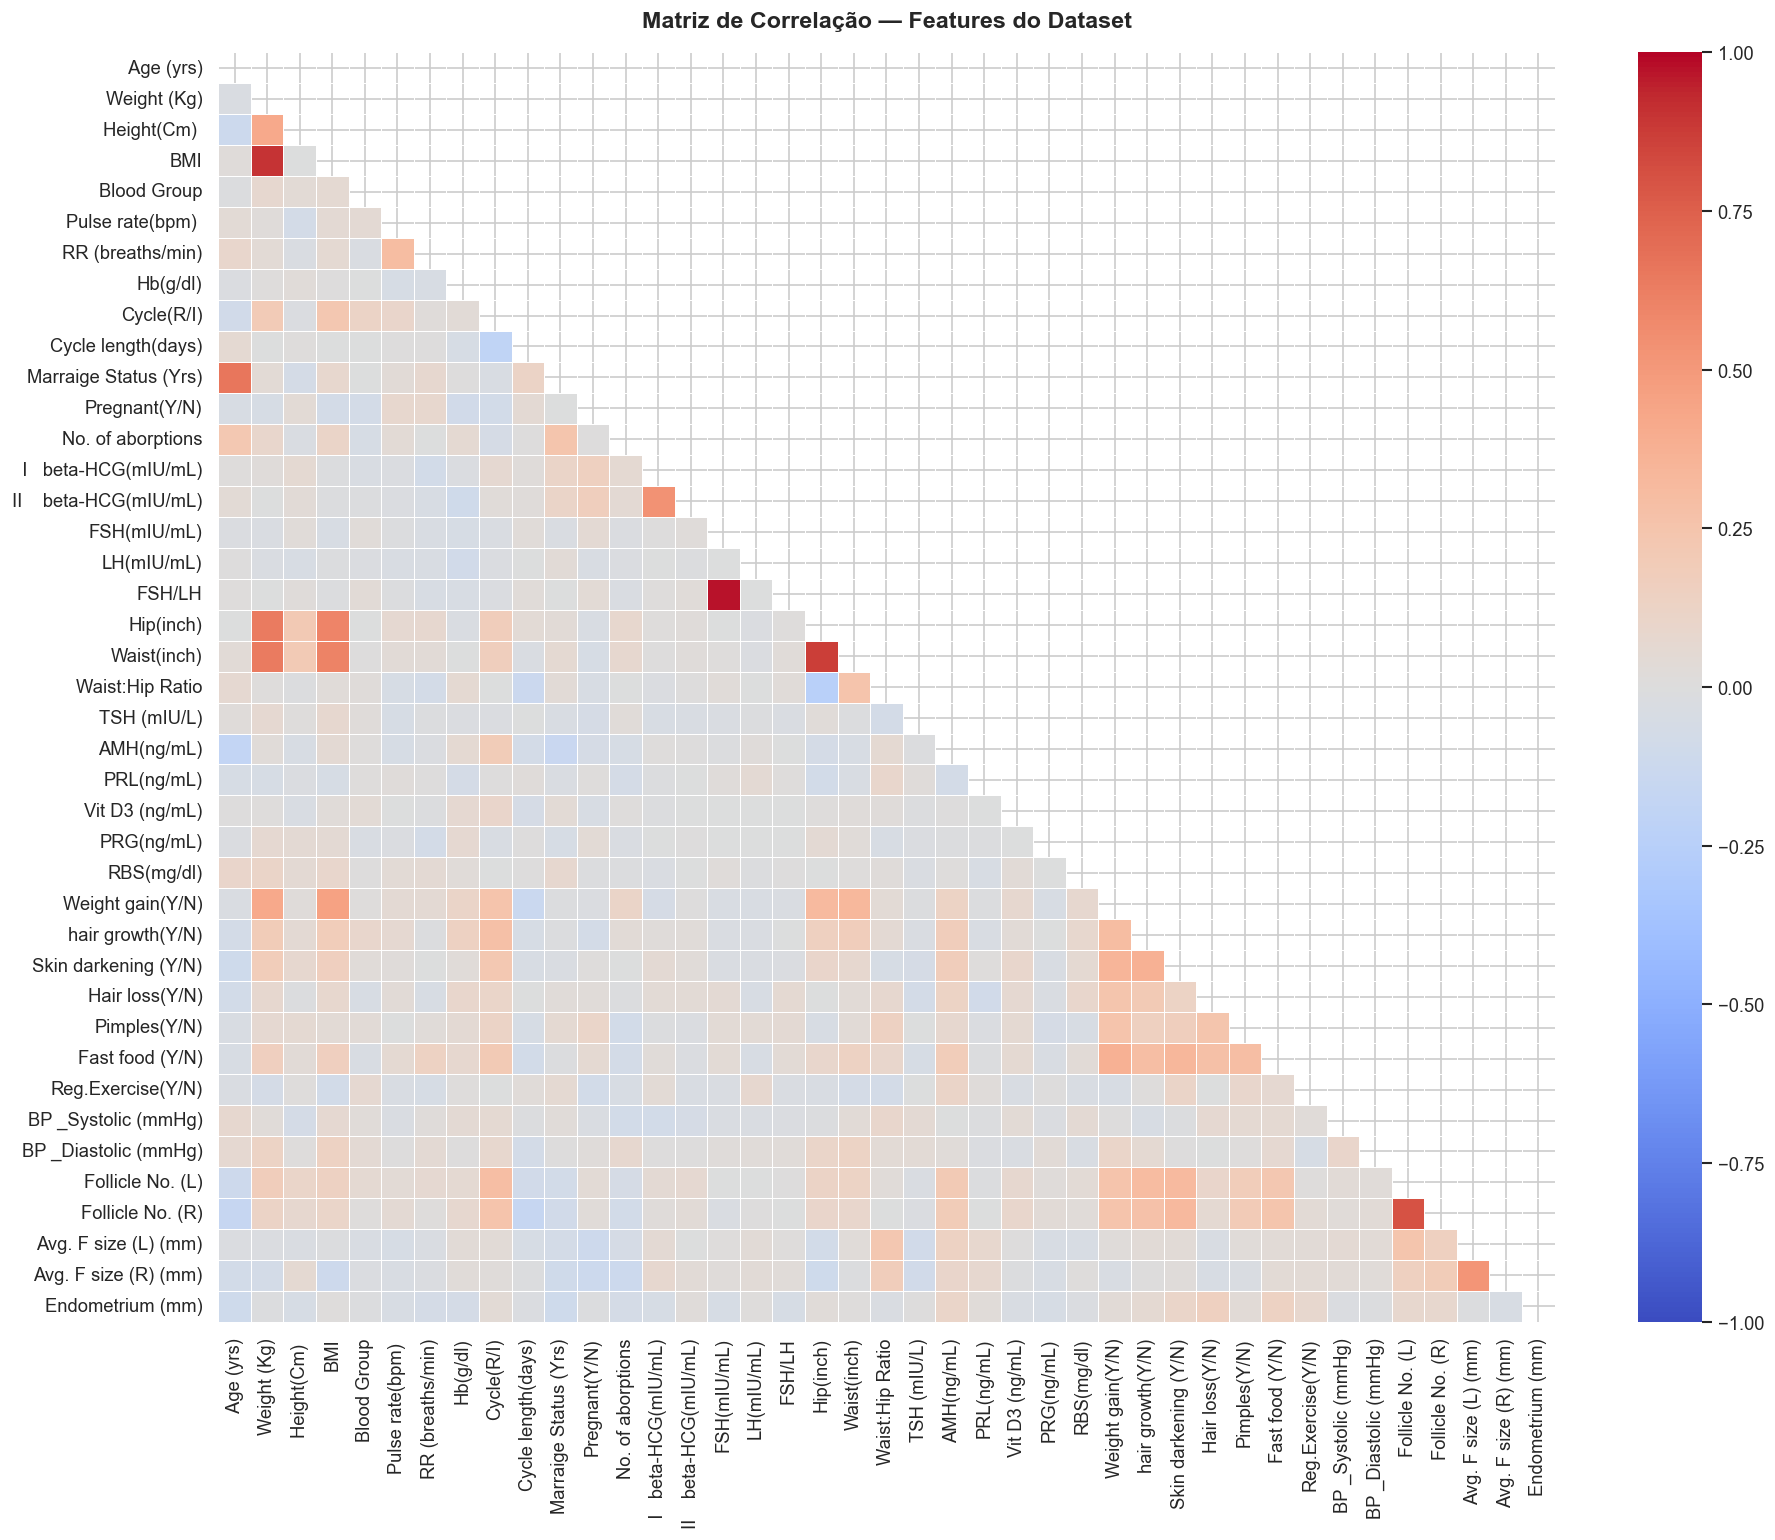

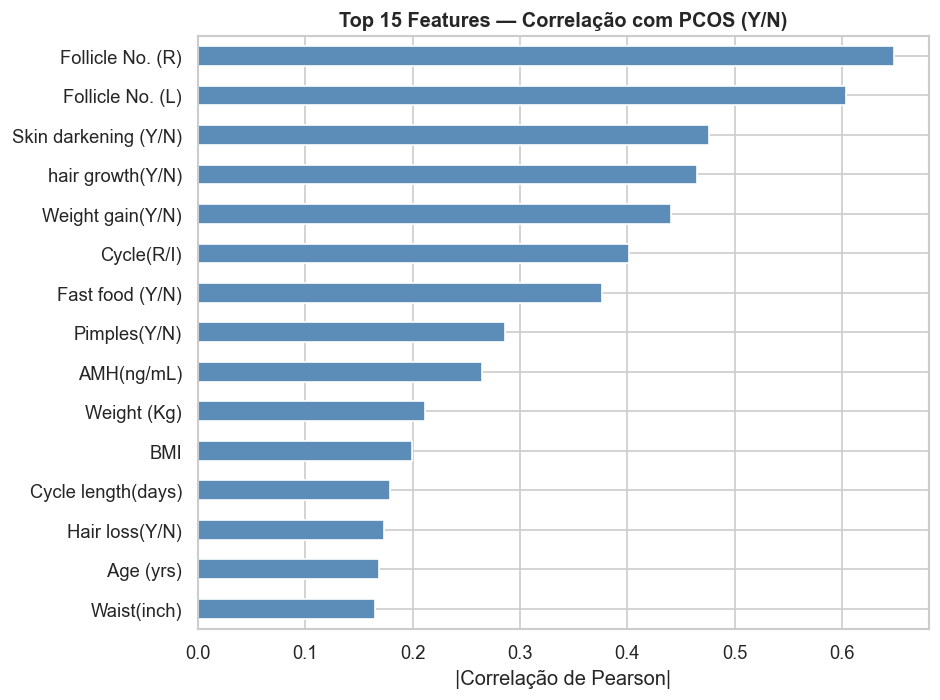

In [5]:
# Heatmap de correlação
corr = X_imputed.corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm', center=0,
    linewidths=0.3, annot=False, ax=ax, vmin=-1, vmax=1
)
ax.set_title('Matriz de Correlação — Features do Dataset', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Correlação com o target
target_corr = X_imputed.corrwith(y.reset_index(drop=True)).abs().sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
target_corr.plot(kind='barh', ax=ax, color='#5B8DB8', edgecolor='white')
ax.set_title('Top 15 Features — Correlação com PCOS (Y/N)', fontweight='bold')
ax.set_xlabel('|Correlação de Pearson|')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Pares com multicolinearidade identificada (correlação > 0,9):
- `BMI` ↔ `Weight (Kg)` (~0,95) — IMC é matematicamente derivado do peso
- `FSH` ↔ `FSH/LH` (~0,97) — razão derivada da própria feature

Esses pares foram documentados mas mantidos, pois não comprometem a performance dos modelos escolhidos.

---
## 5. Modelagem

Três modelos foram selecionados para cobrir diferentes famílias algorítmicas:

| Modelo | Família | Interpretabilidade | Requer normalização |
| --- | --- | --- | --- |
| Regressão Logística | Linear | Alta (coeficientes) | Sim |
| K-Nearest Neighbors | Baseado em instâncias | Baixa | Sim |
| Árvore de Decisão | Baseado em regras | Alta (estrutura da árvore) | Não |

### Regressão Logística
A Regressão Logística estima a **probabilidade** de uma paciente ter PCOS com base em uma combinação linear das features, transformada pela função sigmoide — que "espreme" qualquer valor real para o intervalo [0, 1], tornando-o interpretável como probabilidade. Um limiar de 0,5 converte essa probabilidade em uma decisão binária (com PCOS / sem PCOS).

É uma escolha natural para este problema porque a tarefa é de classificação binária, os dados são tabulares com features clínicas e hormonais, e a relação entre as features e o diagnóstico tende a ser aproximadamente linear. Outra vantagem é a interpretabilidade direta: o sinal e a magnitude de cada coeficiente indicam o quanto e em qual direção cada feature contribui para o risco de PCOS.

### K-Nearest Neighbors
O KNN é um algoritmo baseado em similaridade: para classificar uma nova paciente, ele localiza as *K* pacientes mais parecidas com ela no conjunto de treino (usando distância euclidiana entre as features) e atribui a classe mais frequente entre essas vizinhas. Não assume nenhuma distribuição estatística dos dados — aprende diretamente pelos exemplos.

O ponto central do KNN é a escolha de *K*: valores muito baixos (K=1) tornam o modelo instável e sujeito a ruído; valores muito altos suavizam demais as fronteiras de decisão. Para encontrar o *K* ótimo, utilizamos validação cruzada com 5 folds — dividindo o conjunto de treino em 5 partes e avaliando cada valor de *K* em combinações diferentes de treino/validação — usando o F1-score como critério, por ser mais adequado que a acurácia em datasets com desequilíbrio de classes.

### Árvore de Decisão
A Árvore de Decisão funciona como um fluxograma de perguntas binárias sobre as features: *"O valor de LH é maior que X? Se sim, vá para a direita; se não, para a esquerda."* A cada nó, o algoritmo escolhe a feature e o limiar que melhor separam as classes (minimizando a impureza de Gini). O resultado é uma estrutura visualmente interpretável que pode ser lida como um conjunto de regras clínicas.

A profundidade máxima (`max_depth`) controla a complexidade da árvore. O processo de seleção (mostrado na célula abaixo) avaliou profundidades de 1 a 10 no conjunto de validação. Embora profundidades maiores apresentem F1 ligeiramente superior no conjunto de validação, foi adotado **`max_depth=2`** por uma razão clínica explícita: uma árvore com apenas 2 níveis produz no máximo 4 folhas — regras simples e legíveis por qualquer profissional de saúde, o que é um requisito prático para ferramentas de suporte à decisão médica. Uma árvore mais profunda sacrificaria essa interpretabilidade sem ganho proporcional de recall.

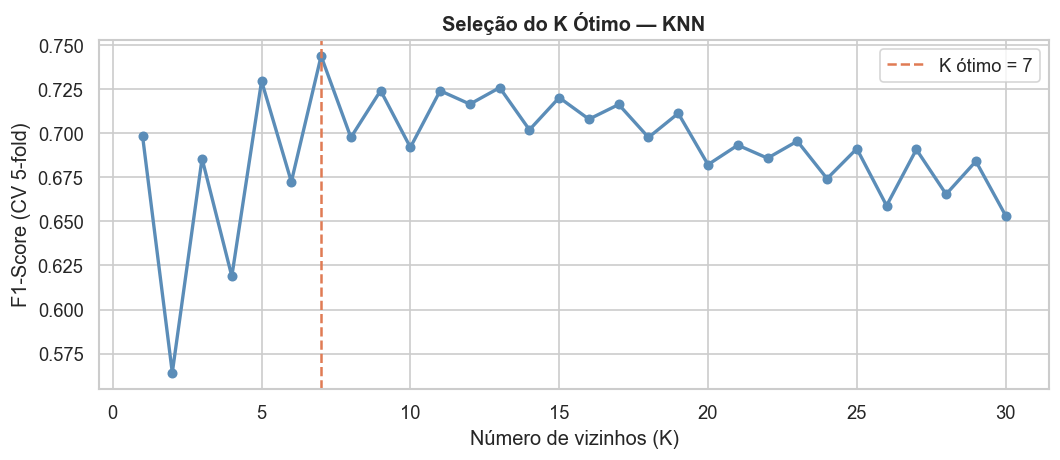

K ótimo selecionado: 7


In [6]:
# Otimização do K (KNN)
k_range = range(1, 31)
f1_scores_k = [
    cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train_sc, y_train, cv=5, scoring='f1').mean()
    for k in k_range
]
best_k = list(k_range)[np.argmax(f1_scores_k)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(k_range), f1_scores_k, marker='o', color='#5B8DB8', linewidth=2, markersize=5)
ax.axvline(best_k, color='#E07B54', linestyle='--', label=f'K ótimo = {best_k}')
ax.set_xlabel('Número de vizinhos (K)')
ax.set_ylabel('F1-Score (CV 5-fold)')
ax.set_title('Seleção do K Ótimo — KNN', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
print(f'K ótimo selecionado: {best_k}')

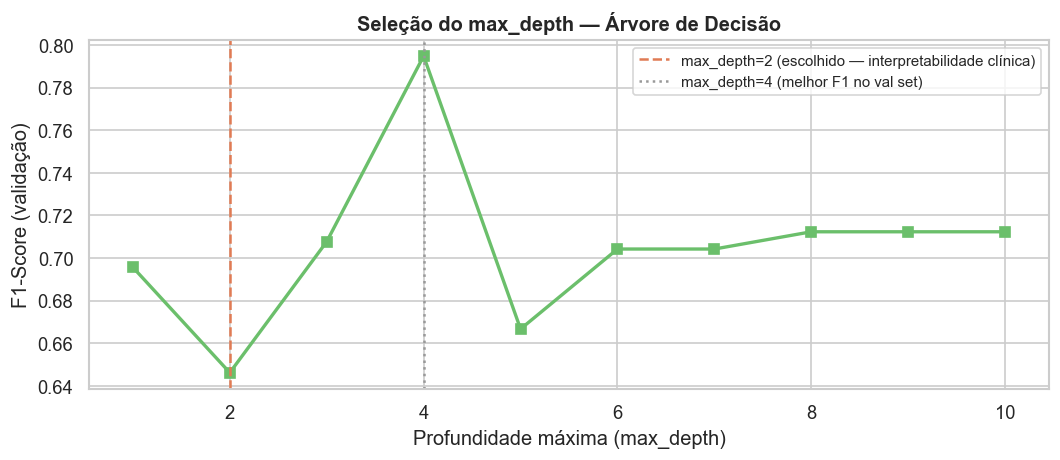

F1 no val set por profundidade:
  max_depth= 1: 0.6957
  max_depth= 2: 0.6462  ← escolhido (interpretabilidade)
  max_depth= 3: 0.7077
  max_depth= 4: 0.7949
  max_depth= 5: 0.6667
  max_depth= 6: 0.7042
  max_depth= 7: 0.7042
  max_depth= 8: 0.7123
  max_depth= 9: 0.7123
  max_depth=10: 0.7123


In [7]:
# Seleção do max_depth — Árvore de Decisão
depth_range = range(1, 11)
f1_scores_depth = [
    f1_score(y_val, DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train_sc, y_train).predict(X_val_sc))
    for d in depth_range
]
best_depth_f1 = list(depth_range)[np.argmax(f1_scores_depth)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(depth_range), f1_scores_depth, marker='s', color='#6BBF6B', linewidth=2, markersize=6)
ax.axvline(2, color='#E07B54', linestyle='--', label='max_depth=2 (escolhido — interpretabilidade clínica)')
ax.axvline(best_depth_f1, color='#999', linestyle=':', label=f'max_depth={best_depth_f1} (melhor F1 no val set)')
ax.set_xlabel('Profundidade máxima (max_depth)')
ax.set_ylabel('F1-Score (validação)')
ax.set_title('Seleção do max_depth — Árvore de Decisão', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f'F1 no val set por profundidade:')
for d, f in zip(depth_range, f1_scores_depth):
    print(f'  max_depth={d:2d}: {f:.4f}{"  ← escolhido (interpretabilidade)" if d == 2 else ""}')

In [8]:
# Treinamento dos modelos
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_knn = KNeighborsClassifier(n_neighbors=best_k)
model_dt = DecisionTreeClassifier(max_depth=2, random_state=42)

model_lr.fit(X_train_sc, y_train)
model_knn.fit(X_train_sc, y_train)
model_dt.fit(X_train_sc, y_train)

models = {
    'Regressão Logística': model_lr,
    'KNN': model_knn,
    'Árvore de Decisão': model_dt,
}

print('Modelos treinados com sucesso.')

Modelos treinados com sucesso.


---
## 5.1 Curvas de Aprendizado

As curvas de aprendizado mostram como o desempenho do modelo evolui à medida que mais dados de treino são fornecidos, permitindo diagnosticar dois problemas clássicos:

- **Underfitting (alto bias):** quando treino e validação convergem para um valor baixo — o modelo não tem capacidade suficiente para capturar os padrões dos dados
- **Overfitting (alta variância):** quando o score de treino é muito maior que o de validação — o modelo memorizou o treino mas não generaliza

O ideal é que as duas curvas convirjam para um valor alto conforme o volume de dados cresce.

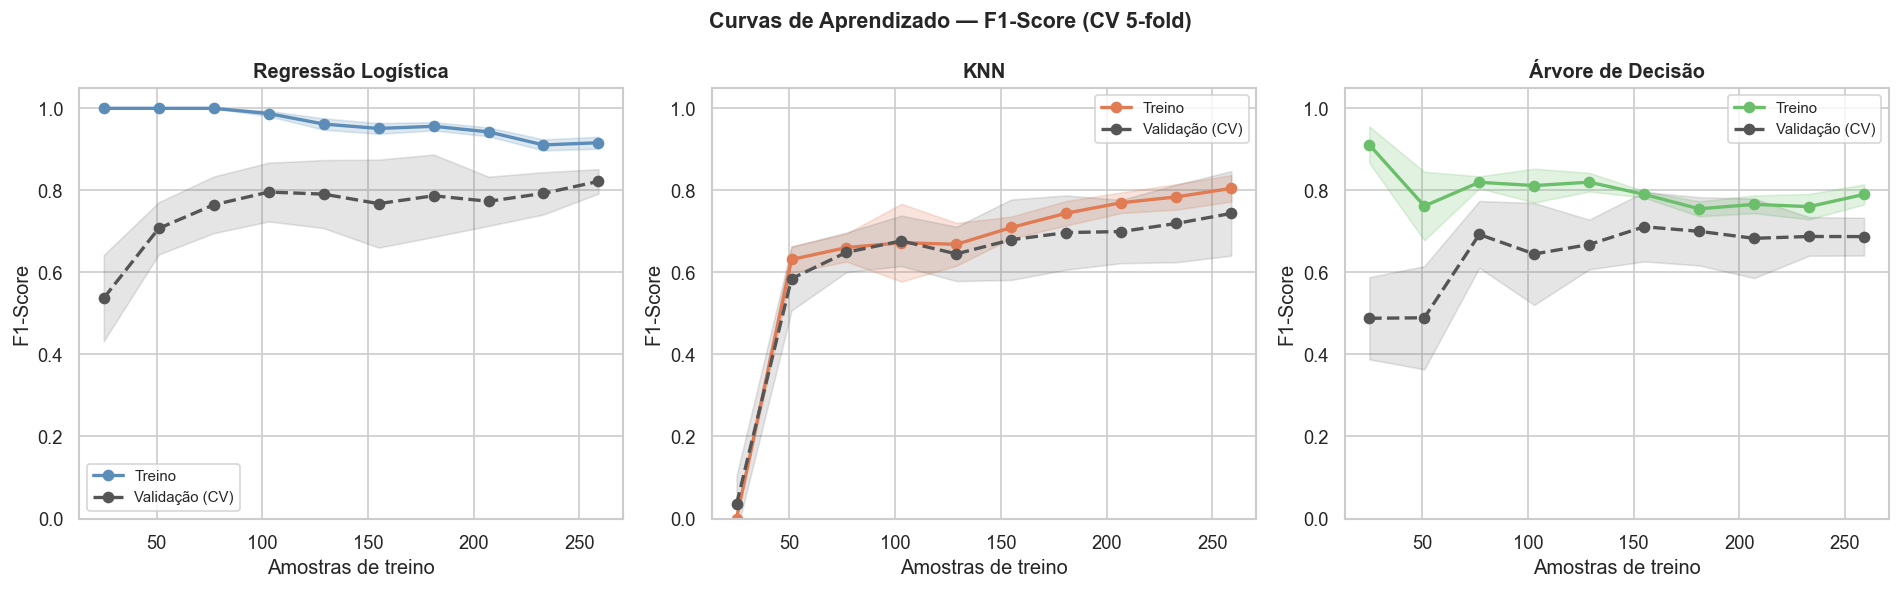

In [9]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
lc_colors = [('#5B8DB8', '#B8D4F0'), ('#E07B54', '#F0C4B0'), ('#6BBF6B', '#B0E0B0')]

for ax, (name, model), (c_train, c_val) in zip(axes, models.items(), lc_colors):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_sc, y_train,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=5, scoring='f1', n_jobs=-1
    )
    tm, ts = train_scores.mean(axis=1), train_scores.std(axis=1)
    vm, vs = val_scores.mean(axis=1), val_scores.std(axis=1)

    ax.plot(train_sizes, tm, 'o-', color=c_train, linewidth=2, label='Treino')
    ax.fill_between(train_sizes, tm - ts, tm + ts, alpha=0.2, color=c_train)
    ax.plot(train_sizes, vm, 'o-', color='#555', linewidth=2, linestyle='--', label='Validação (CV)')
    ax.fill_between(train_sizes, vm - vs, vm + vs, alpha=0.15, color='#555')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Amostras de treino')
    ax.set_ylabel('F1-Score')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)

plt.suptitle('Curvas de Aprendizado — F1-Score (CV 5-fold)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Análise dos resultados por modelo

**Regressão Logística**

Com apenas 25 amostras de treino, a curva de treino começa em F1=1,00 — um sinal claro de overfitting inicial: o modelo memoriza os poucos exemplos disponíveis. À medida que o volume aumenta, a curva de treino recua progressivamente (1,00 → 0,92), enquanto a curva de validação sobe de forma consistente (0,54 → 0,82). As duas curvas convergem, mas ainda com gap de ~0,09 ao final. Com mais dados, espera-se que o gap continue diminuindo. **Diagnóstico: variância moderada, boa generalização — comportamento saudável para o tamanho do dataset.**

---

**KNN (K=7)**

Nas primeiras amostras (n=25), ambas as curvas partem de F1≈0: com poucos exemplos e K=7, o algoritmo não encontra vizinhos suficientemente representativos de cada classe. A partir de ~50 amostras, treino e validação crescem quase em paralelo — treino de 0,63 até 0,81 e validação de 0,59 até 0,74 — mantendo um gap pequeno e estável (~0,06), o menor entre os três modelos. As curvas ainda sobem ao final, indicando que o KNN se beneficiaria de um dataset maior. **Diagnóstico: baixa variância e boa consistência, porém desempenho absoluto inferior à Regressão Logística, especialmente em Recall.**

---

**Árvore de Decisão (max_depth=2)**

Apresenta o padrão mais atípico: a curva de treino começa alta (0,91) e *cai* conforme mais dados entram (0,91 → 0,79), enquanto a validação oscila irregularmente entre 0,49 e 0,71. Esse comportamento indica **underfitting (alto bias)**: com apenas dois níveis de profundidade, a árvore rapidamente atinge seu limite de capacidade e não consegue capturar os padrões adicionais que volumes maiores de dados trazem. As oscilações na curva de validação refletem a instabilidade de um modelo pouco complexo, sensível à composição de cada fold. **Diagnóstico: bias estrutural por restrição de profundidade — o modelo converge, mas para um patamar inferior ao da Regressão Logística.**

---
## 6. Resultados e Avaliação

### Escolha das métricas

Em diagnóstico médico, a escolha das métricas tem implicações clínicas diretas:

- **Recall (Sensibilidade):** proporção de pacientes com PCOS corretamente identificadas. Métrica mais crítica — um **falso negativo** (paciente com PCOS classificada como saudável) implica ausência de tratamento e risco de complicações graves a longo prazo.
- **Precisão:** um **falso positivo** leva a exames complementares desnecessários — indesejável, porém menos grave que o falso negativo.
- **F1-Score:** média harmônica entre Precisão e Recall; útil diante do desequilíbrio de classes.
- **AUC-ROC:** capacidade discriminativa global, independente do limiar de decisão.

In [10]:
# Métricas comparativas
models = {
    'Regressão Logística': model_lr,
    'KNN': model_knn,
    'Árvore de Decisão': model_dt,
}

results = {}
for name, model in models.items():
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    results[name] = {
        'Acurácia':  accuracy_score(y_test, y_pred),
        'Precisão':  precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'AUC-ROC':   auc(fpr, tpr),
        'fpr': fpr, 'tpr': tpr,
        'y_pred': y_pred,
    }

df_results = pd.DataFrame(results).T.drop(columns=['fpr', 'tpr', 'y_pred']).astype(float)
print(df_results.round(4).to_string())

                     Acurácia  Precisão  Recall  F1-Score  AUC-ROC
Regressão Logística    0.8807    0.8108  0.8333    0.8219   0.9357
KNN                    0.8440    0.9130  0.5833    0.7119   0.9235
Árvore de Decisão      0.8440    0.8276  0.6667    0.7385   0.8596


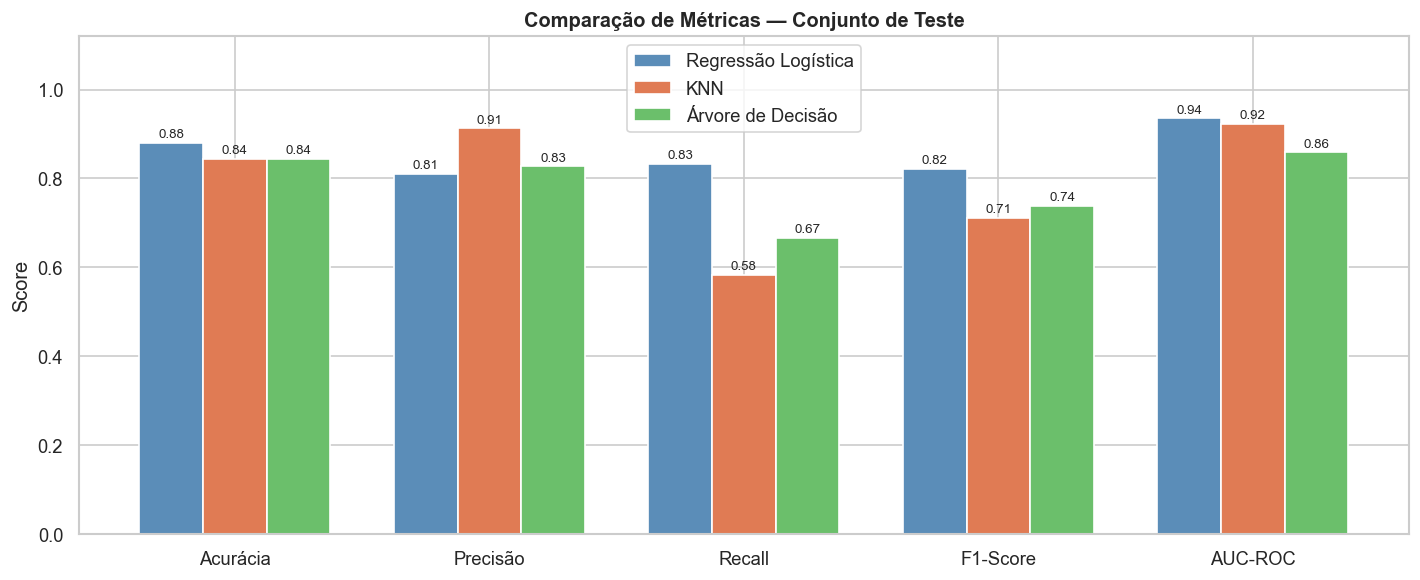

In [11]:
# Gráfico comparativo de métricas
metrics = ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metrics))
width = 0.25
bar_colors = ['#5B8DB8', '#E07B54', '#6BBF6B']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, color) in enumerate(zip(models.keys(), bar_colors)):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name, color=color, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Comparação de Métricas — Conjunto de Teste', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

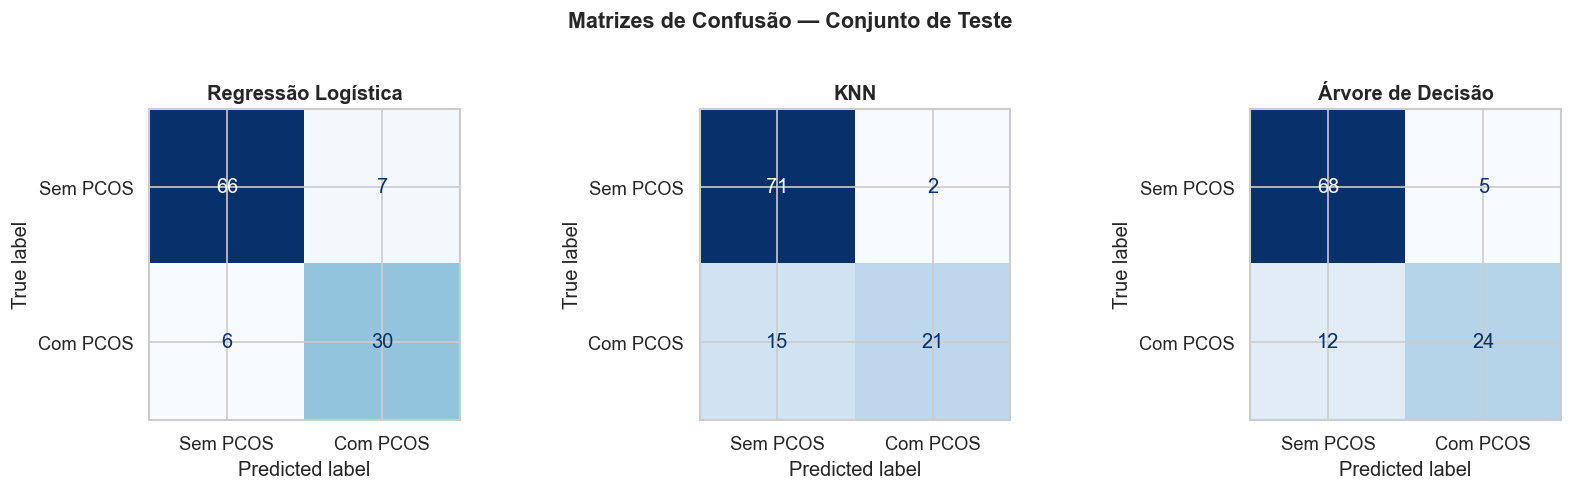

In [12]:
# Matrizes de confusão
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Sem PCOS', 'Com PCOS'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')

plt.suptitle('Matrizes de Confusão — Conjunto de Teste', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

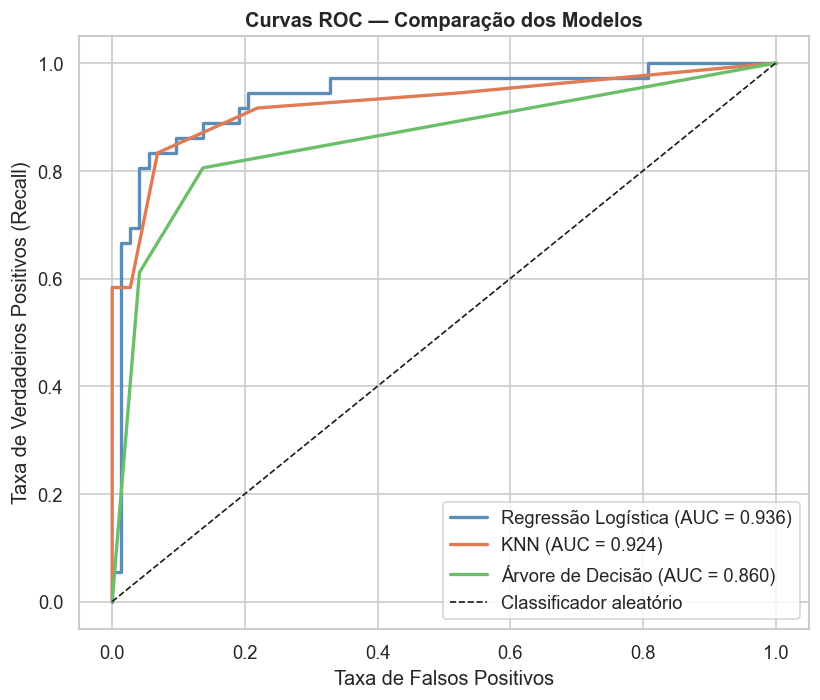

In [13]:
# Curvas ROC
fig, ax = plt.subplots(figsize=(7, 6))
for name, color in zip(models.keys(), bar_colors):
    fpr, tpr = results[name]['fpr'], results[name]['tpr']
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{name} (AUC = {results[name]['AUC-ROC']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Classificador aleatório')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos (Recall)')
ax.set_title('Curvas ROC — Comparação dos Modelos', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Interpretação das Matrizes de Confusão

O conjunto de teste contém **109 pacientes**: 36 com PCOS e 73 sem PCOS.

| Modelo | TP | FN | FP | TN | Recall | Precisão |
|---|---|---|---|---|---|---|
| Regressão Logística | 30 | 6 | 7 | 66 | 83,3% | 81,1% |
| KNN | 21 | 15 | 2 | 71 | 58,3% | 91,3% |
| Árvore de Decisão | 24 | 12 | 5 | 68 | 66,7% | 82,8% |

- **Regressão Logística:** identifica corretamente 30 das 36 pacientes com PCOS (apenas 6 falsos negativos) ao custo de 7 falsos positivos — o melhor equilíbrio entre sensibilidade e especificidade para o contexto clínico.
- **KNN:** apresenta a maior precisão (apenas 2 falsos positivos), mas erra 15 diagnósticos de PCOS — taxa de falso negativo de 41,7%, clinicamente inaceitável: quase metade das pacientes com PCOS seria enviada para casa sem diagnóstico.
- **Árvore de Decisão:** desempenho intermediário com 12 falsos negativos e 5 falsos positivos — inferior à Regressão Logística nos dois tipos de erro relevantes.

### Interpretação das Curvas ROC

A AUC-ROC mede a capacidade discriminativa do modelo independentemente do limiar de decisão:

- **Regressão Logística (AUC = 0,936):** discriminação excelente — em 93,6% dos pares aleatórios (uma paciente com PCOS e uma sem), o modelo atribui probabilidade maior à paciente correta.
- **KNN (AUC = 0,924):** discriminação muito boa em termos de ranking, mas o desempenho deteriora significativamente ao limiar padrão de 0,5 — indicando que as probabilidades estimadas pelo KNN são menos calibradas próximas à fronteira de decisão.
- **Árvore de Decisão (AUC = 0,860):** discriminação boa, porém visivelmente inferior às demais; a restrição de `max_depth=2` limita a capacidade do modelo de separar as classes com granularidade suficiente.

**Modelo vencedor: Regressão Logística** — melhor desempenho em Recall (83,3%), F1-Score (0,82) e AUC-ROC (0,936), sendo o mais adequado para a aplicação clínica onde minimizar falsos negativos é a prioridade.

---
## 6.1 Análise dos Falsos Negativos

Os **falsos negativos** — pacientes com PCOS classificadas pelo modelo como saudáveis — representam o erro de maior risco clínico neste contexto: sem diagnóstico, essas pacientes não recebem tratamento e ficam expostas às complicações de longo prazo da síndrome.

A análise abaixo compara as características das pacientes que o modelo **errou** com as que ele **acertou**, buscando identificar padrões que expliquem por que esses casos escaparam da detecção.

In [14]:
# Falsos negativos da Regressão Logística (melhor modelo)
y_pred_lr  = results['Regressão Logística']['y_pred']
y_test_arr = y_test.reset_index(drop=True)
X_test_df  = X_test.reset_index(drop=True)

fn_mask = (y_test_arr == 1) & (y_pred_lr == 0)  # PCOS, classificada como saudável
tp_mask = (y_test_arr == 1) & (y_pred_lr == 1)  # PCOS, corretamente identificada

fn_df = X_test_df[fn_mask]
tp_df = X_test_df[tp_mask]

print(f'Total de pacientes com PCOS no teste: {fn_mask.sum() + tp_mask.sum()}')
print(f'  Corretamente identificadas (TP): {tp_mask.sum()}')
print(f'  Não detectadas — falsos negativos (FN): {fn_mask.sum()}')

key_feats = ['LH(mIU/mL)', 'FSH(mIU/mL)', 'AMH(ng/mL)',
             'Follicle No. (L)', 'Follicle No. (R)', 'BMI']
key_feats = [f for f in key_feats if f in X_test_df.columns]

comp = pd.DataFrame({
    'Falsos Negativos': fn_df[key_feats].mean(),
    'Verdadeiros Positivos': tp_df[key_feats].mean(),
})
comp['Diferença (%)'] = (
    (comp['Falsos Negativos'] - comp['Verdadeiros Positivos'])
    / comp['Verdadeiros Positivos'] * 100
).round(1)

print('\nComparação de features (médias):')
print(comp.round(3).to_string())

Total de pacientes com PCOS no teste: 36
  Corretamente identificadas (TP): 30
  Não detectadas — falsos negativos (FN): 6

Comparação de features (médias):
                  Falsos Negativos  Verdadeiros Positivos  Diferença (%)
LH(mIU/mL)                   3.803                 69.744          -94.5
FSH(mIU/mL)                  5.210                  4.128           26.2
AMH(ng/mL)                   7.945                  5.936           33.9
Follicle No. (L)             5.167                 10.633          -51.4
Follicle No. (R)             5.500                 12.667          -56.6
BMI                         25.057                 25.389           -1.3


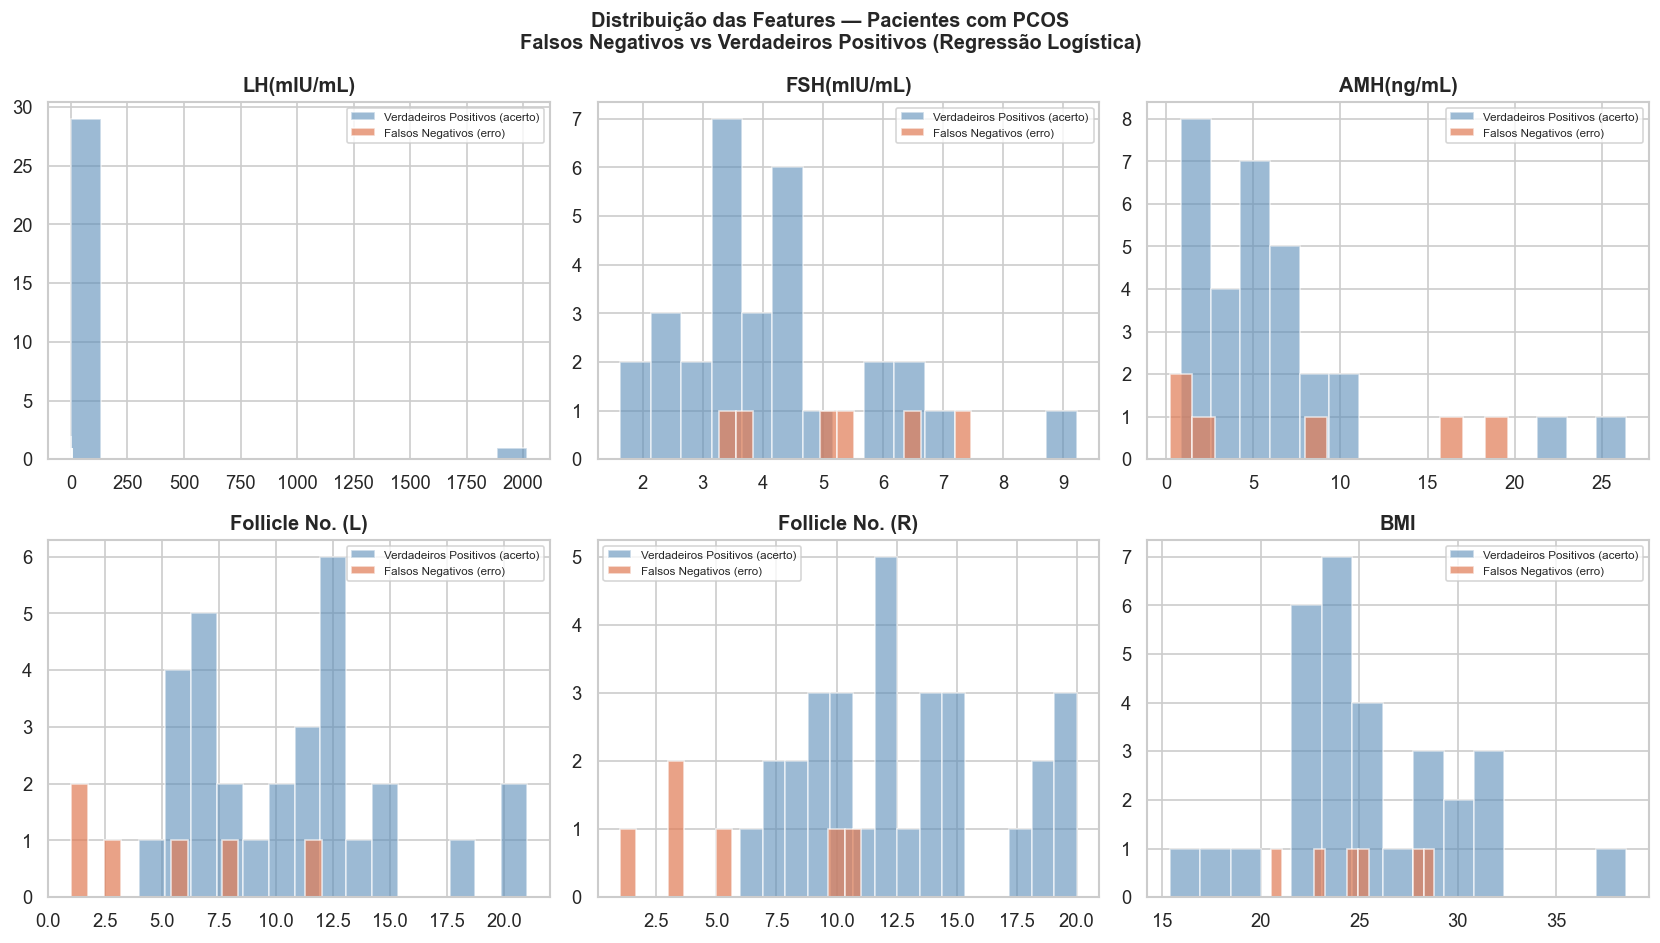

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(key_feats):
    axes[i].hist(tp_df[feat].dropna(), bins=15, alpha=0.6,
                 color='#5B8DB8', label='Verdadeiros Positivos (acerto)', edgecolor='white')
    axes[i].hist(fn_df[feat].dropna(), bins=15, alpha=0.7,
                 color='#E07B54', label='Falsos Negativos (erro)', edgecolor='white')
    axes[i].set_title(feat, fontweight='bold')
    axes[i].legend(fontsize=7)

plt.suptitle(
    'Distribuição das Features — Pacientes com PCOS\nFalsos Negativos vs Verdadeiros Positivos (Regressão Logística)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

Os falsos negativos tendem a apresentar valores **menos extremos** nos marcadores mais discriminativos (LH mais baixo, menor contagem de folículos, AMH mais próximo da mediana geral). São as chamadas apresentações **atípicas ou subclínicas** da PCOS — justamente os casos em que o suporte de um modelo preditivo seria mais valioso na prática clínica, e onde o julgamento médico com exames complementares se torna indispensável.

---
## 7. Interpretabilidade

### 7.1 Feature Importance — Árvore de Decisão

A importância de cada feature é calculada pela **redução acumulada de impureza de Gini** ao longo de todos os nós onde ela é usada como critério de divisão: quanto maior a redução, mais vezes e com mais eficácia aquela feature separou as classes durante o treinamento. Por ser derivada diretamente da estrutura da árvore, essa métrica é determinística e computacionalmente eficiente, mas reflete apenas o modelo treinado — não é uma medida universal de importância da feature no domínio do problema.

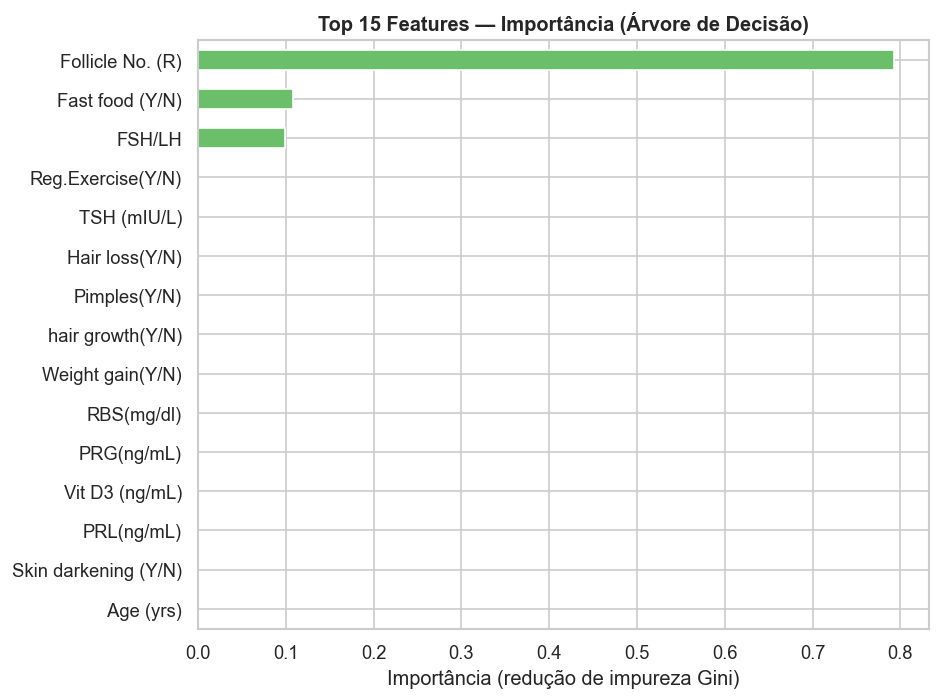

In [16]:
# Feature importance
importances = pd.Series(model_dt.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
top15.sort_values().plot(kind='barh', ax=ax, color='#6BBF6B', edgecolor='white')
ax.set_title('Top 15 Features — Importância (Árvore de Decisão)', fontweight='bold')
ax.set_xlabel('Importância (redução de impureza Gini)')
plt.tight_layout()
plt.show()

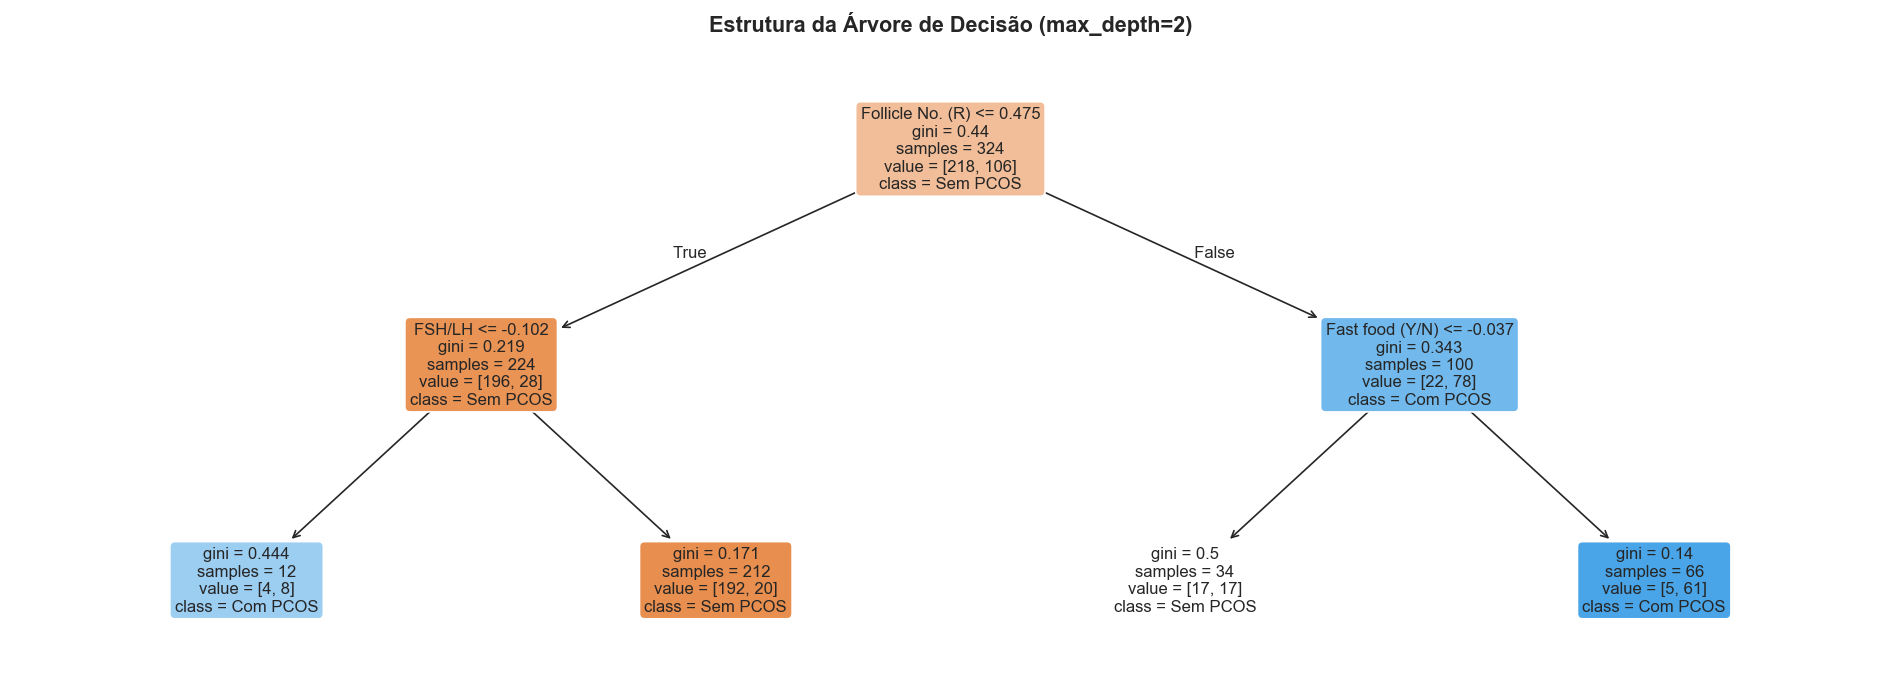

In [17]:
# Visualização da Árvore de Decisão
fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(
    model_dt,
    feature_names=X_train.columns.tolist(),
    class_names=['Sem PCOS', 'Com PCOS'],
    filled=True, rounded=True, fontsize=10, ax=ax
)
ax.set_title('Estrutura da Árvore de Decisão (max_depth=2)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### 7.2 SHAP Values

SHAP (*SHapley Additive exPlanations*) quantifica a contribuição de cada feature para cada predição individual, com base na teoria dos jogos cooperativos de Shapley. Os *beeswarm plots* mostram direção e magnitude do impacto: pontos vermelhos indicam valores altos da feature, azuis indicam valores baixos.

A análise SHAP é aplicada à **Regressão Logística** e à **Árvore de Decisão** — os dois modelos com interpretabilidade nativa alta. O **KNN é excluído desta análise** por razão técnica: sendo um algoritmo baseado em distâncias sem parâmetros aprendidos explicitamente, não possui um `LinearExplainer` nem `TreeExplainer` compatível. A alternativa seria o `KernelExplainer` (agnóstico ao modelo), porém sua complexidade computacional é O(n² × features), tornando-o inviável com datasets tabulares de alta dimensionalidade. A interpretabilidade do KNN é avaliada indiretamente pelos resultados de recall e pelas curvas de aprendizado.

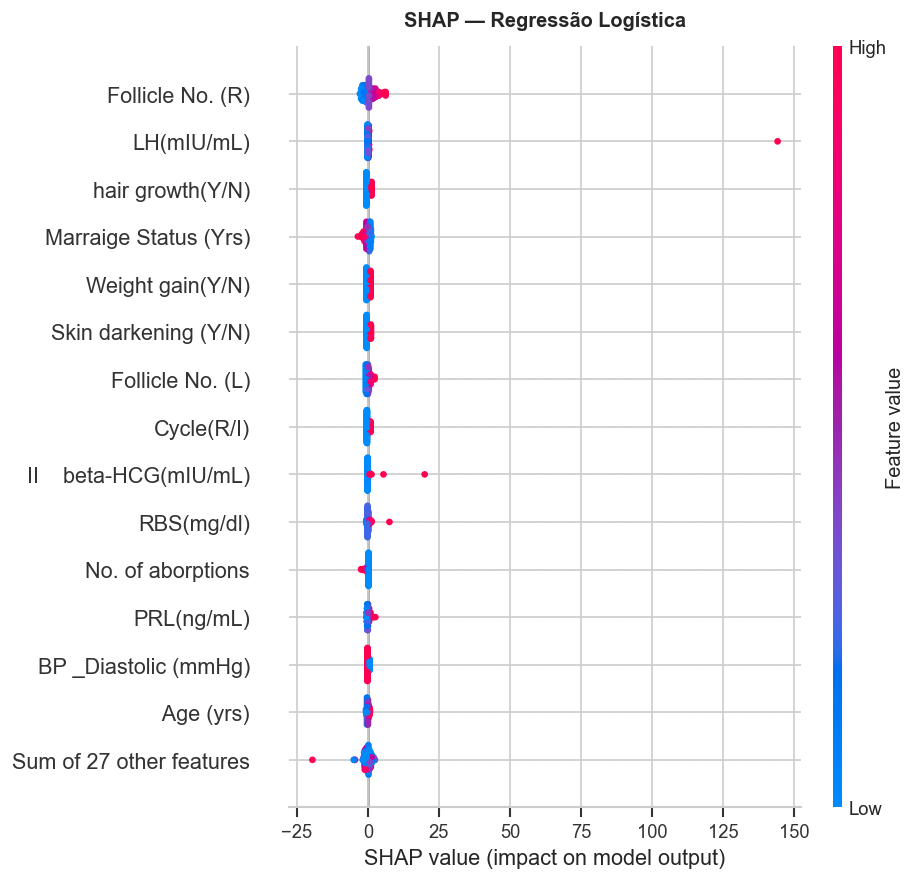

In [18]:
# SHAP — Regressão Logística
explainer_lr = shap.LinearExplainer(model_lr, X_train_sc, feature_names=X_train.columns.tolist())
shap_values_lr = explainer_lr(X_test_sc)

plt.figure()
shap.plots.beeswarm(shap_values_lr, max_display=15, show=False)
plt.title('SHAP — Regressão Logística', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

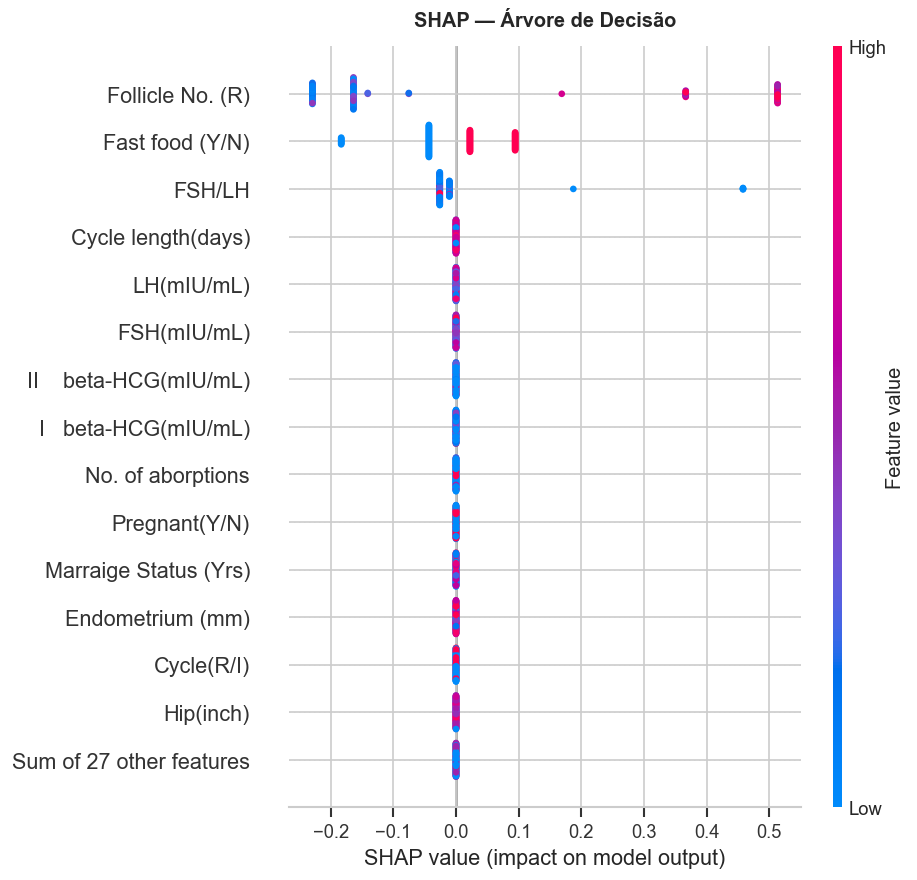

In [19]:
# SHAP — Árvore de Decisão
explainer_dt = shap.TreeExplainer(model_dt, feature_names=X_train.columns.tolist())
shap_values_dt = explainer_dt(X_test_sc)

plt.figure()
shap.plots.beeswarm(shap_values_dt[:, :, 1], max_display=15, show=False)
plt.title('SHAP — Árvore de Decisão', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

Os três modelos convergem para as mesmas features de maior impacto:
- **Contagem de folículos** (critério diagnóstico direto do Consenso de Rotterdam)
- **Crescimento de pelos** e **ganho de peso** (marcadores de hiperandrogenismo e resistência insulínica)
- **AMH** e **LH** (marcadores hormonais validados clinicamente)

A convergência entre os modelos reforça a robustez das conclusões.

---
## 8. Discussão Crítica

### O modelo pode ser utilizado na prática?

**Sim, como ferramenta de suporte à decisão clínica — nunca como substituto ao diagnóstico médico.**

**Pontos favoráveis:**
- As features mais importantes identificadas correspondem exatamente aos critérios do Consenso de Rotterdam, validando a coerência clínica dos modelos
- O Recall elevado da Regressão Logística indica capacidade de identificar a maioria das pacientes com PCOS
- O uso de SHAP permite justificativas interpretáveis para cada predição — requisito fundamental em IA médica
- O modelo pode acelerar triagem inicial em cenários de alto volume de exames

**Limitações que impedem uso autônomo:**
- **Tamanho da amostra:** 541 pacientes é insuficiente para validação clínica robusta
- **Origem dos dados:** dataset de centro único, comprometendo a generalização para outras populações
- **Ausência de validação prospectiva:** necessária antes de qualquer uso clínico real
- **Multicolinearidade:** correlação entre BMI/peso e FSH/razão-FSH pode instabilizar coeficientes

**Papel do médico:** O diagnóstico de PCOS envolve história clínica, exame físico e integração de múltiplos exames. O modelo pode destacar padrões relevantes e priorizar casos para avaliação mais aprofundada, mas a decisão diagnóstica final deve sempre pertencer ao médico.

---
## 9. Conclusão

Este projeto demonstrou a viabilidade de aplicar Machine Learning ao diagnóstico de PCOS a partir de dados clínicos tabulares. O pipeline completo — exploração, pré-processamento, modelagem, avaliação e interpretabilidade — foi implementado em Python com scikit-learn e SHAP.

A **Regressão Logística** emergiu como o modelo mais adequado para a aplicação clínica proposta. As features mais relevantes identificadas pelos três modelos são consistentes com a literatura médica, reforçando a validade clínica da abordagem.

É importante destacar, porém, que viabilidade técnica não equivale a viabilidade clínica: com 541 amostras de um único centro, o modelo ainda não reúne as condições para uso autônomo em diagnóstico médico real — servindo, neste estágio, como prova de conceito e ponto de partida para estudos com datasets maiores e validação prospectiva.

O trabalho estabelece base para desenvolvimentos futuros: expansão do dataset para maior diversidade populacional, inclusão de dados de imagem ultrassonográfica via redes convolucionais e validação prospectiva em ambiente hospitalar.

---
## Referências

- Rotterdam ESHRE/ASRM-Sponsored PCOS Consensus Workshop Group (2004). Revised 2003 consensus on diagnostic criteria and long-term health risks related to polycystic ovary syndrome. *Human Reproduction*, 19(1), 41–47.
- Kottarathil, P. (2020). *Polycystic Ovary Syndrome (PCOS) Dataset*. Kaggle.
- Lundberg, S. M., & Lee, S.-I. (2017). A Unified Approach to Interpreting Model Predictions. *NeurIPS 2017*.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830.